# Exploratory Data Analysis (EDA) for the Weather Scraping Project

This notebook explores the processed weather dataset collected from **Open-Meteo**, **Weather Underground**, and **Time and Date**.

## Goals
- understand the structure and quality of the scraped data
- check missing values, duplicates, and suspicious values
- compare weather patterns across cities and sources
- extract useful insights for the final report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")


candidate_paths = [
    Path("../data/processed/weather_data.csv"),
    Path("data/processed/weather_data.csv"),
]

data_path = None
for path in candidate_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find data/processed/weather_data.csv")

print("Using file:", data_path.resolve())


Using file: C:\Users\Lenovo\Desktop\WebScraping\data\processed\weather_data.csv


## 1. Load the dataset

In [2]:
df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


Shape: (21277, 9)


,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition
0,TimeAndDate,Auckland,New Zealand,2026-02-28 00:00:00+00:00,27.0,19.0,100.0,9.00,NaN
1,TimeAndDate,Beirut,Lebanon,2026-02-28 00:00:00+00:00,24.0,40.0,96.0,14.48,NaN
2,TimeAndDate,Berlin,Germany,2026-02-28 00:00:00+00:00,16.0,40.0,100.0,9.00,NaN
3,TimeAndDate,Buenos Aires,Argentina,2026-02-28 00:00:00+00:00,32.0,28.0,100.0,15.00,NaN
4,TimeAndDate,Cairo,Egypt,2026-02-28 00:00:00+00:00,27.0,25.0,88.0,24.00,NaN


## 2. Basic overview

In [3]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nInfo:")
df.info()



Columns:
['SourceWebsite', 'City', 'Country', 'ScrapeDateTime', 'Temperature_C', 'FeelsLike_C', 'Humidity_%', 'WindSpeed_kmh', 'Condition']

Data types:
SourceWebsite         str
City                  str
Country               str
ScrapeDateTime        str
Temperature_C     float64
FeelsLike_C       float64
Humidity_%        float64
WindSpeed_kmh     float64
Condition             str
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 21277 entries, 0 to 21276
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SourceWebsite   21277 non-null  str    
 1   City            21277 non-null  str    
 2   Country         21277 non-null  str    
 3   ScrapeDateTime  21277 non-null  str    
 4   Temperature_C   21277 non-null  float64
 5   FeelsLike_C     21277 non-null  float64
 6   Humidity_%      21277 non-null  float64
 7   WindSpeed_kmh   21277 non-null  float64
 8   Condition       19969 non-null  str    

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SourceWebsite,21277,3,Open-Meteo,18000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,21277,26,Beirut,1160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,21277,27,United States,2449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScrapeDateTime,21277,4459,2026-03-29 00:00:00+00:00,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature_C,21277.0,NaN,NaN,NaN,18.008728,10.297195,-10.4,11.0,17.5,23.9,60.0
FeelsLike_C,21277.0,NaN,NaN,NaN,17.592085,12.415871,-18.7,8.6,17.0,24.5,60.0
Humidity_%,21277.0,NaN,NaN,NaN,70.826479,20.029506,6.0,57.0,74.0,87.0,100.0
WindSpeed_kmh,21277.0,NaN,NaN,NaN,10.233114,6.390733,0.0,5.4,9.0,13.8,43.8
Condition,19969,75,clear sky,5902,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Initial data quality checks

In [5]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
SourceWebsite        0
City                 0
Country              0
ScrapeDateTime       0
Temperature_C        0
FeelsLike_C          0
Humidity_%           0
WindSpeed_kmh        0
Condition         1308
dtype: int64

Duplicate rows: 0


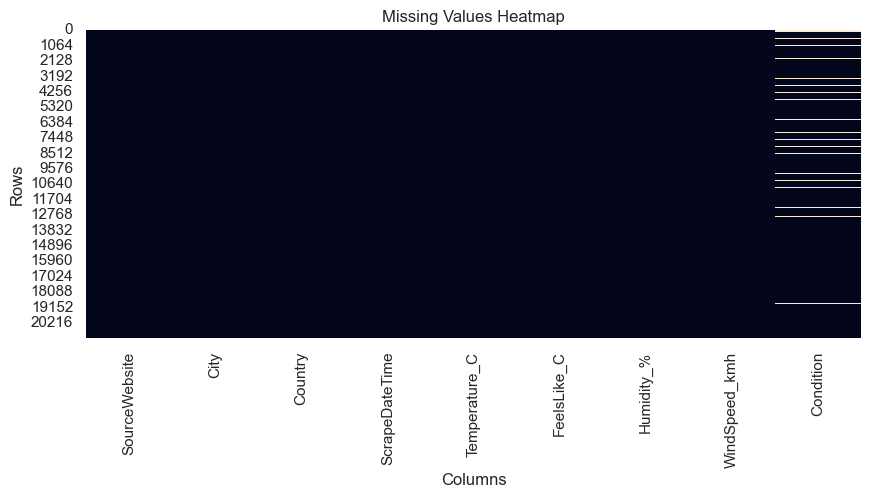

In [6]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


## 4. Datetime cleaning and feature engineering

The original notebook converted `ScrapeDateTime`, but did not use it afterward.
Here we convert it properly and create extra time-based columns for analysis.

In [7]:
df.columns = df.columns.str.strip()

df["ScrapeDateTime"] = (
    df["ScrapeDateTime"]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan})
)

df["ScrapeDateTime"] = pd.to_datetime(
    df["ScrapeDateTime"],
    errors="coerce",
    utc=True
)

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
else:
    df["Date"] = df["ScrapeDateTime"].dt.date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["ScrapeHour"] = df["ScrapeDateTime"].dt.hour
df["ScrapeDay"] = df["ScrapeDateTime"].dt.day_name()

print(df[["Date", "ScrapeDateTime", "ScrapeHour", "ScrapeDay"]].head())


        Date            ScrapeDateTime  ScrapeHour ScrapeDay
0 2026-02-28 2026-02-28 00:00:00+00:00         0.0  Saturday
1 2026-02-28 2026-02-28 00:00:00+00:00         0.0  Saturday
2 2026-02-28 2026-02-28 00:00:00+00:00         0.0  Saturday
3 2026-02-28 2026-02-28 00:00:00+00:00         0.0  Saturday
4 2026-02-28 2026-02-28 00:00:00+00:00         0.0  Saturday


In [8]:
print("Date range from Date column:")
print("Min:", df["Date"].min())
print("Max:", df["Date"].max())

print("\nDate range from ScrapeDateTime column:")
print("Min:", df["ScrapeDateTime"].min())
print("Max:", df["ScrapeDateTime"].max())


Date range from Date column:
Min: 2026-02-28 00:00:00
Max: 2026-04-07 00:00:00

Date range from ScrapeDateTime column:
Min: 2026-02-28 00:00:00+00:00
Max: 2026-04-07 23:00:00+00:00


## 5. Categorical variables

In [9]:
print("Unique cities:", df["City"].nunique())
print("Unique countries:", df["Country"].nunique())
print("Unique source websites:", df["SourceWebsite"].nunique())

print("\nSource counts:")
print(df["SourceWebsite"].value_counts())

print("\nTop weather conditions:")
print(df["Condition"].value_counts(dropna=False).head(15))


Unique cities: 26
Unique countries: 27
Unique source websites: 3

Source counts:
SourceWebsite
Open-Meteo            18000
TimeAndDate            2705
WeatherUnderground      572
Name: count, dtype: int64

Top weather conditions:
Condition
clear sky           5902
overcast            5726
mainly clear        1999
light drizzle       1717
partly cloudy       1586
NaN                 1308
moderate drizzle     402
clear.               300
passing clouds.      297
slight rain          288
moderate rain        179
sunny.               175
dense drizzle        146
mostly cloudy        104
overcast.             97
Name: count, dtype: int64


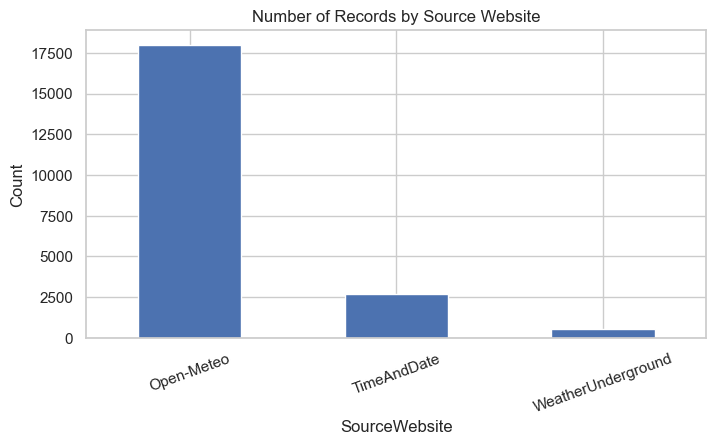

In [10]:
plt.figure(figsize=(8, 4))
df["SourceWebsite"].value_counts().plot(kind="bar")
plt.title("Number of Records by Source Website")
plt.xlabel("SourceWebsite")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


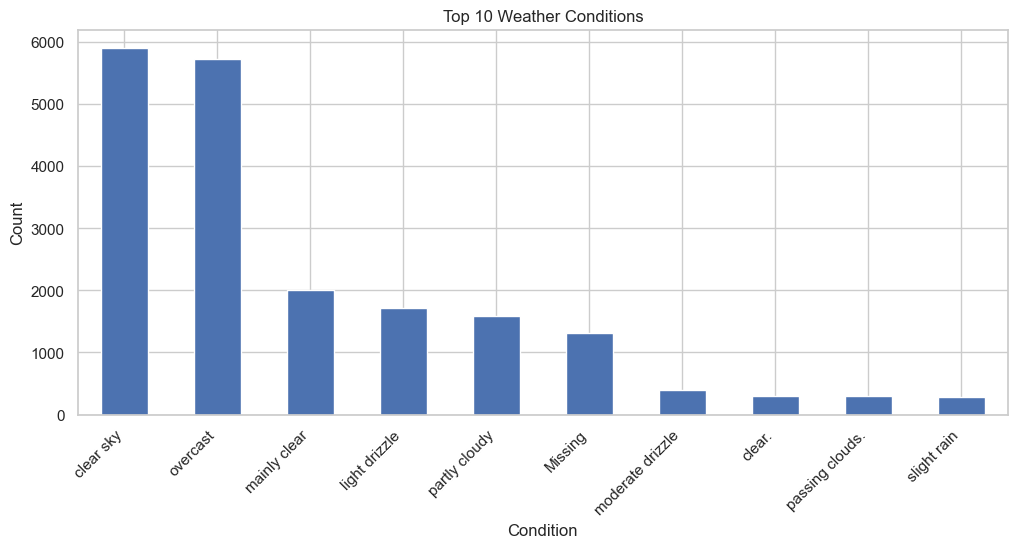

In [11]:
plt.figure(figsize=(12, 5))
df["Condition"].fillna("Missing").value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Weather Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()


## 6. Numerical variable distributions

In [12]:
numeric_cols = ["Temperature_C", "FeelsLike_C", "Humidity_%", "WindSpeed_kmh"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Temperature_C,21277.0,18.008728,10.297195,-10.4,11.0,17.5,23.9,60.0
FeelsLike_C,21277.0,17.592085,12.415871,-18.7,8.6,17.0,24.5,60.0
Humidity_%,21277.0,70.826479,20.029506,6.0,57.0,74.0,87.0,100.0
WindSpeed_kmh,21277.0,10.233114,6.390733,0.0,5.4,9.0,13.8,43.8


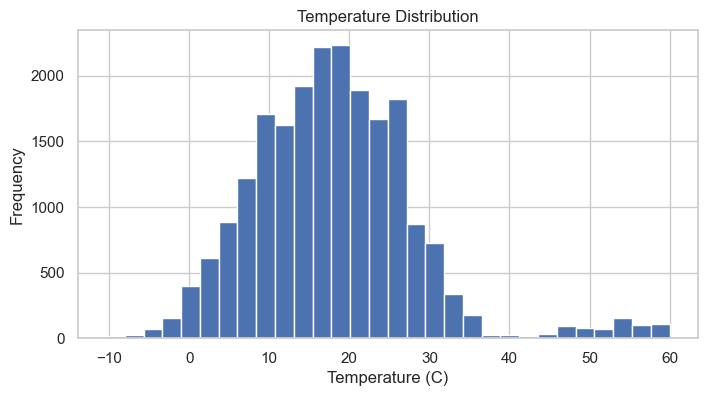

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df["Temperature_C"].dropna(), bins=30)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (C)")
plt.ylabel("Frequency")
plt.show()


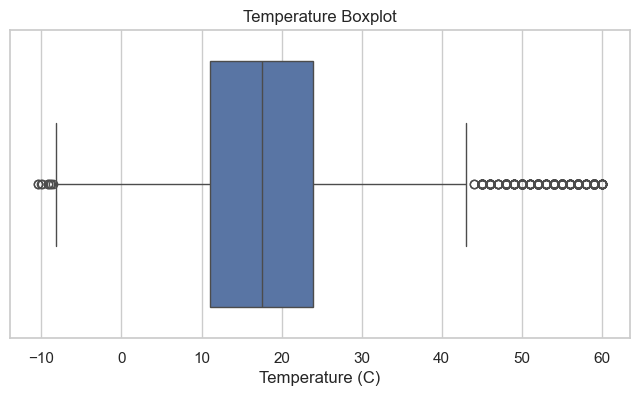

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Temperature_C"])
plt.title("Temperature Boxplot")
plt.xlabel("Temperature (C)")
plt.show()


## 7. Suspicious values / anomaly checks

This section is useful in scraping projects because strange values may come from:
- unit conversion issues
- parsing problems
- site structure changes
- missing or incorrectly scraped fields

In [15]:
print("Rows with Temperature_C > 50:")
display(df[df["Temperature_C"] > 50].head(10))

print("Rows with Temperature_C < -20:")
display(df[df["Temperature_C"] < -20].head(10))


Rows with Temperature_C > 50:


,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,Date,ScrapeHour,ScrapeDay
13238,WeatherUnderground,London,United Kingdom,NaT,53.0,7.0,78.0,20.92,cloudy,NaT,NaN,NaN
13239,WeatherUnderground,London,United Kingdom,NaT,55.0,7.0,78.0,24.14,light rain,NaT,NaN,NaN
13293,WeatherUnderground,Auckland,New Zealand,NaT,51.0,17.5,79.0,14.48,fair,NaT,NaN,NaN
13324,WeatherUnderground,London,United Kingdom,NaT,53.0,7.0,78.0,20.92,cloudy,NaT,NaN,NaN
13325,WeatherUnderground,London,United Kingdom,NaT,55.0,7.0,78.0,24.14,light rain,NaT,NaN,NaN
13341,WeatherUnderground,Rome,Italy,NaT,53.0,10.7,73.0,20.92,cloudy,NaT,NaN,NaN
13409,WeatherUnderground,Sao Paulo,Brazil,NaT,53.0,21.0,94.0,11.27,cloudy,NaT,NaN,NaN
13415,WeatherUnderground,London,United Kingdom,NaT,53.0,7.0,78.0,20.92,cloudy,NaT,NaN,NaN
13416,WeatherUnderground,London,United Kingdom,NaT,54.0,7.0,78.0,22.53,showers,NaT,NaN,NaN
13417,WeatherUnderground,London,United Kingdom,NaT,55.0,7.0,78.0,24.14,light rain,NaT,NaN,NaN


Rows with Temperature_C < -20:


,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,Date,ScrapeHour,ScrapeDay


In [16]:
print("Rows with Humidity_% outside 0-100:")
display(df[(df["Humidity_%"] < 0) | (df["Humidity_%"] > 100)])

print("Rows with negative wind speed:")
display(df[df["WindSpeed_kmh"] < 0])


Rows with Humidity_% outside 0-100:


,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,Date,ScrapeHour,ScrapeDay


Rows with negative wind speed:


,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,Date,ScrapeHour,ScrapeDay


### Important note

If one source has much higher temperatures than the others, that may indicate a **unit mismatch**
(for example Fahrenheit values being stored as Celsius).

In [17]:
source_temp_summary = df.groupby("SourceWebsite")["Temperature_C"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean")
source_temp_summary


,count,mean,median,min,max
SourceWebsite,,,,,
Open-Meteo,18000,16.073033,16.400000,-10.400000,39.8
WeatherUnderground,572,25.814880,23.333333,13.888889,55.0
TimeAndDate,2705,29.238817,27.000000,0.000000,60.0


## 8. City-level analysis

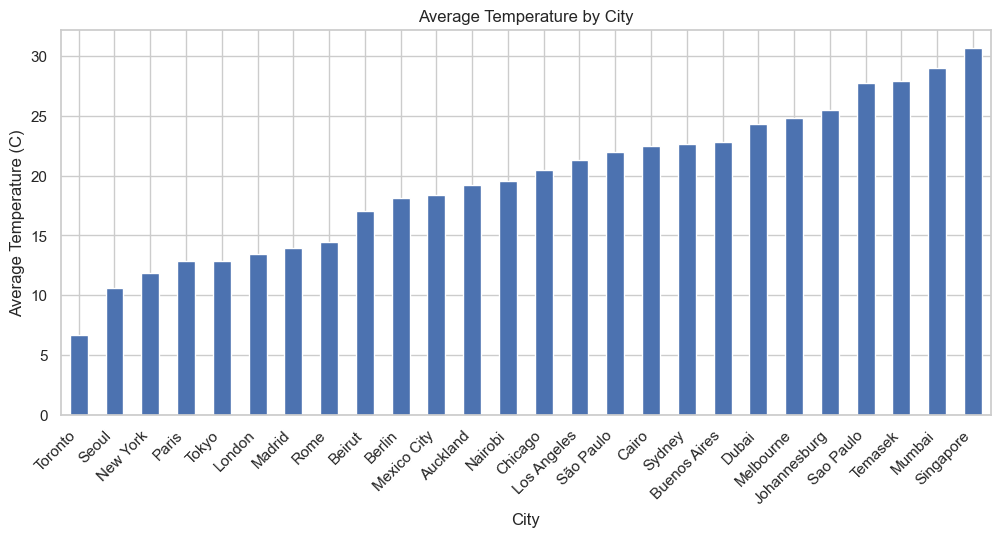

City
Toronto          6.650191
Seoul           10.605637
New York        11.897594
Paris           12.838328
Tokyo           12.869314
London          13.465650
Madrid          13.915472
Rome            14.430004
Beirut          17.044138
Berlin          18.165951
Mexico City     18.390218
Auckland        19.216426
Nairobi         19.563902
Chicago         20.461026
Los Angeles     21.299710
São Paulo       21.985068
Cairo           22.446008
Sydney          22.677624
Buenos Aires    22.843960
Dubai           24.277831
Melbourne       24.860989
Johannesburg    25.471248
Sao Paulo       27.748084
Temasek         27.880794
Mumbai          28.999464
Singapore       30.664665
Name: Temperature_C, dtype: float64

In [18]:
city_temp = (
    df.groupby("City")["Temperature_C"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 5))
city_temp.plot(kind="bar")
plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature (C)")
plt.xticks(rotation=45, ha="right")
plt.show()

city_temp


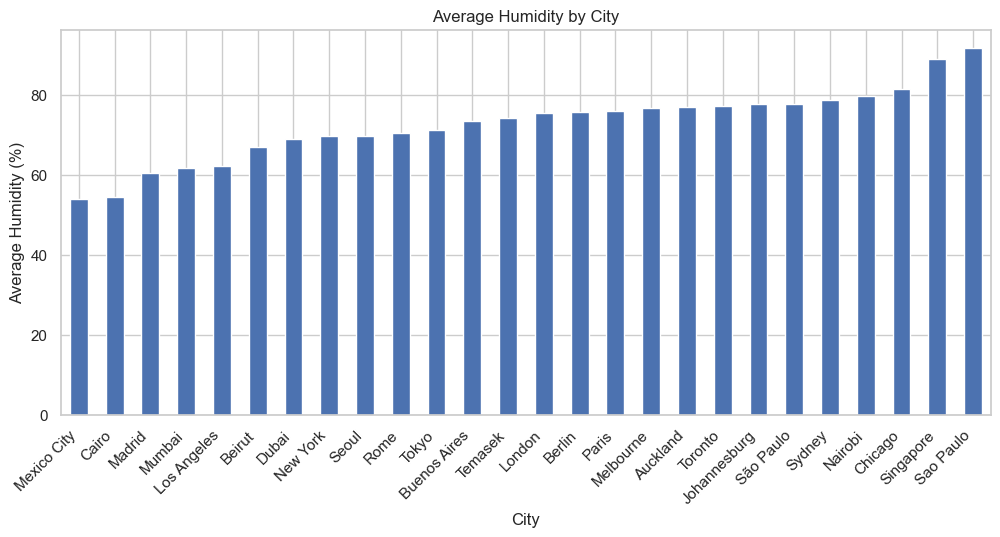

In [19]:
city_humidity = (
    df.groupby("City")["Humidity_%"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 5))
city_humidity.plot(kind="bar")
plt.title("Average Humidity by City")
plt.xlabel("City")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=45, ha="right")
plt.show()


## 9. Source comparison

In [20]:
source_summary = df.groupby("SourceWebsite")[numeric_cols].mean().round(2)
source_summary


,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh
SourceWebsite,,,,
Open-Meteo,16.07,15.22,68.57,9.74
TimeAndDate,29.24,33.69,85.18,12.67
WeatherUnderground,25.81,16.27,73.97,14.11


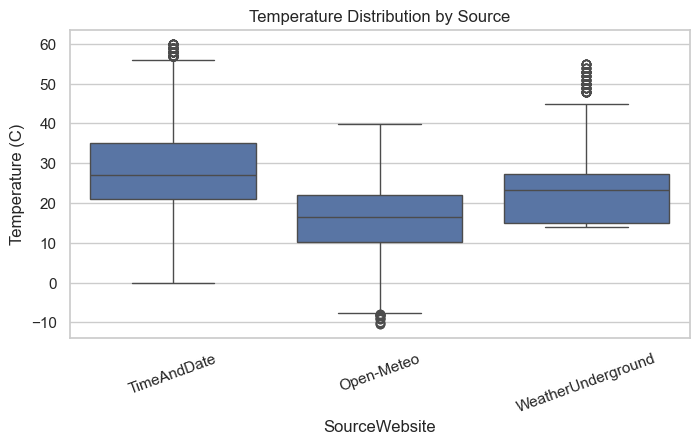

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="SourceWebsite", y="Temperature_C")
plt.title("Temperature Distribution by Source")
plt.xlabel("SourceWebsite")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=20)
plt.show()


This is one of the most important sections in your project, because the project is based on comparing
multiple scraped sources, not just describing one dataset.

## 10. Relationships between numerical features

In [22]:
corr = df[numeric_cols].corr(numeric_only=True)
corr


,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh
Temperature_C,1.000000,0.879948,-0.103234,0.117439
FeelsLike_C,0.879948,1.000000,0.027509,0.015440
Humidity_%,-0.103234,0.027509,1.000000,-0.074459
WindSpeed_kmh,0.117439,0.015440,-0.074459,1.000000


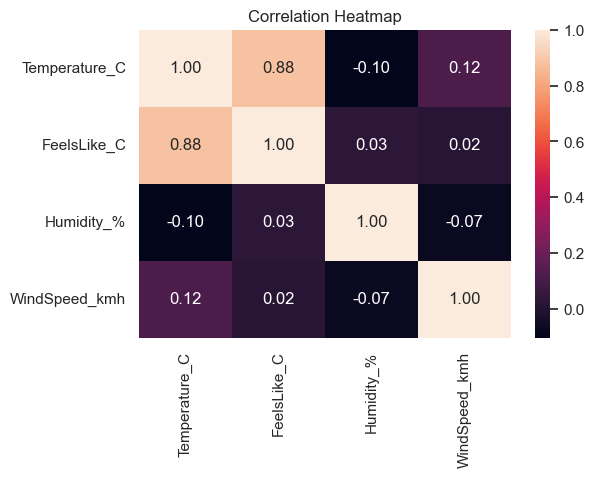

In [23]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


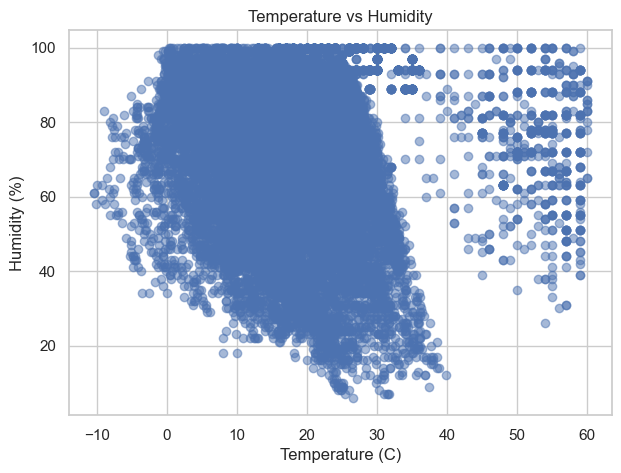

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Temperature_C"], df["Humidity_%"], alpha=0.5)
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")
plt.show()


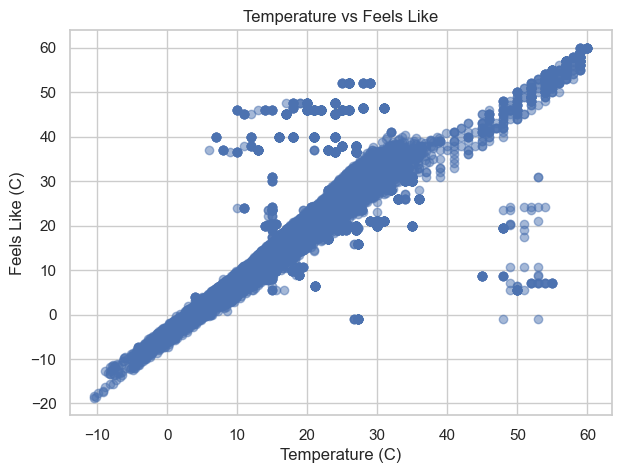

In [25]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Temperature_C"], df["FeelsLike_C"], alpha=0.5)
plt.xlabel("Temperature (C)")
plt.ylabel("Feels Like (C)")
plt.title("Temperature vs Feels Like")
plt.show()


## 11. Time-based analysis

In [26]:
time_df = df.dropna(subset=["ScrapeDateTime"]).sort_values("ScrapeDateTime").copy()

print("Rows with valid ScrapeDateTime:", len(time_df))
time_df[["ScrapeDateTime", "Temperature_C", "SourceWebsite", "City"]].head()


Rows with valid ScrapeDateTime: 17685


,ScrapeDateTime,Temperature_C,SourceWebsite,City
0,2026-02-28 00:00:00+00:00,27.0,TimeAndDate,Auckland
23,2026-02-28 00:00:00+00:00,13.0,TimeAndDate,Toronto
22,2026-02-28 00:00:00+00:00,21.0,TimeAndDate,Tokyo
21,2026-02-28 00:00:00+00:00,30.0,TimeAndDate,Sydney
20,2026-02-28 00:00:00+00:00,34.0,TimeAndDate,Singapore


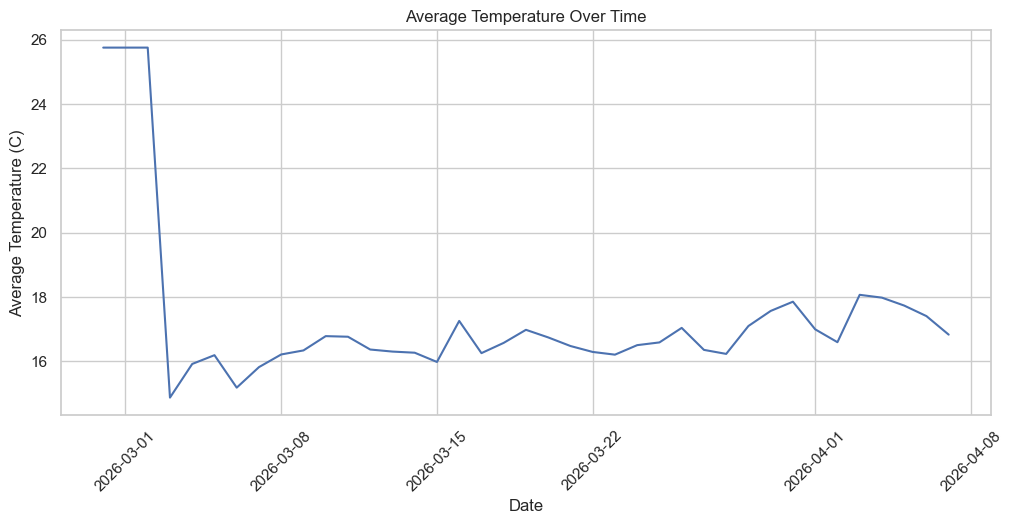

In [27]:
daily_temp = (
    time_df.groupby(time_df["ScrapeDateTime"].dt.date)["Temperature_C"]
    .mean()
)

plt.figure(figsize=(12, 5))
daily_temp.plot()
plt.title("Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Average Temperature (C)")
plt.xticks(rotation=45)
plt.show()


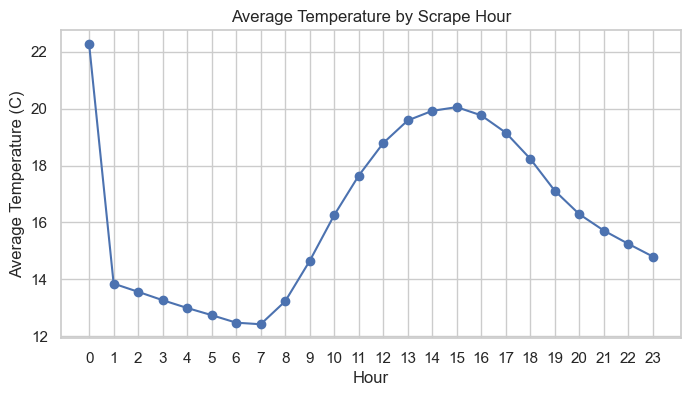

In [28]:
hourly_temp = time_df.groupby("ScrapeHour")["Temperature_C"].mean()

plt.figure(figsize=(8, 4))
hourly_temp.plot(marker="o")
plt.title("Average Temperature by Scrape Hour")
plt.xlabel("Hour")
plt.ylabel("Average Temperature (C)")
plt.xticks(range(0, 24))
plt.show()
